# Supplementary Figure 14: simplified coupling between transposition and maximum PCN capacity

This sensitivity imposes a twofold capacity coupling: actual maximum PCN capacity equals nominal $n$ in the −transposition condition and $2n$ in the +transposition condition. This is a specified model robustness test; it is not an empirical estimate of the direction or magnitude of transposase–PCN coupling.


In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("SIM_RUN_MODE", "production")
%run ./simulation_core.ipynb
plt.rcParams.update(PLOT_STYLE)

OUTPUT_ROOT, FIGURE_DIR, SOURCE_DIR = make_output_dirs("Supplementary_Figure_14_outputs")
NOMINAL_GRID=(np.array([100],dtype=int) if RUN_MODE=="quick" else np.arange(20,101,5,dtype=int))
CONDITIONS=("transposition on","transposition off")


## Converged coupling sweep and figure


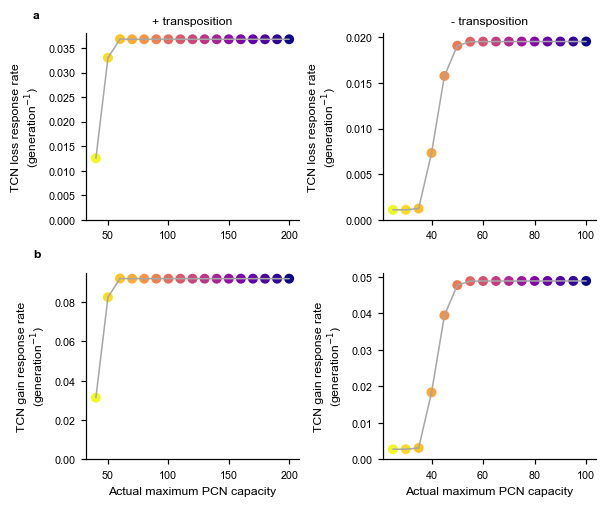

In [2]:
rows=[]
for nominal in NOMINAL_GRID:
    for condition in CONDITIONS:
        actual=int(2*nominal if condition=="transposition on" else nominal)
        if condition=="transposition on": kf,kb=TRANSITIONS.kappa_f_on,TRANSITIONS.kappa_b_on
        else: kf,kb=TRANSITIONS.kappa_f_off,TRANSITIONS.kappa_b_off
        config=make_configuration(actual,condition=condition,kappa_f=kf,kappa_b=kb,setting_label="2x capacity coupling")
        r=evaluate_configuration(actual,config)
        r.update({"nominal_maximum_PCN":int(nominal),"actual_maximum_PCN":actual})
        rows.append(r)
results=pd.DataFrame(rows)

fig,axes=plt.subplots(2,2,figsize=(5.4,4.5),constrained_layout=True)
for row,(metric,phase) in enumerate((("loss_rate","Loss"),("gain_rate","Gain"))):
    for col,condition in enumerate(CONDITIONS):
        ax=axes[row,col]
        d=results[(results.condition==condition)&results.response_valid].sort_values("actual_maximum_PCN")
        ax.plot(d.actual_maximum_PCN,d[metric],color="0.65",lw=1)
        ax.scatter(d.actual_maximum_PCN,d[metric],c=d.actual_maximum_PCN,cmap="plasma_r",s=30)
        ax.set_ylim(bottom=0)
        ax.set_ylabel(f"TCN {phase.lower()} response rate\n(generation$^{{-1}}$)")
        if row==1: ax.set_xlabel("Actual maximum PCN capacity")
        if row==0: ax.set_title("+ transposition" if condition=="transposition on" else "- transposition")
axes[0,0].text(-0.25,1.08,"a",transform=axes[0,0].transAxes,fontweight="bold")
axes[1,0].text(-0.25,1.08,"b",transform=axes[1,0].transAxes,fontweight="bold")
save_figure(fig,"Supplementary_Figure_14_capacity_coupling",FIGURE_DIR); plt.show()

export_table(results,"Supplementary_Figure_14_source_data.csv",SOURCE_DIR)
export_table(core_metadata("Supplementary Figure 14"),"Supplementary_Figure_14_run_metadata.csv",SOURCE_DIR)
